# Step 5.5 — KPI-Driven Reward Optimization

This notebook adds a manager-focused optimization step between Step 5 and Step 6.

Goal: compute operational KPIs from your data, compare them to target business goals, and derive tuned reward weights for RL training.

## What we do in this step (simple view)

1. Load `case_step_features` and baseline reward outputs.
2. Build case-level KPI tables by municipality.
3. Compare KPI baseline vs manager targets.
4. Convert KPI gaps into suggested reward-weight adjustments.
5. Save KPI report and tuned reward-weight JSON for downstream use.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path('./output')
FEATURES_PARQUET = OUTPUT_DIR / 'case_step_features.parquet'
FEATURES_CSV = OUTPUT_DIR / 'case_step_features.csv'
REWARD_CASE_PATH = OUTPUT_DIR / 'reward_case_summary.csv'
KPI_SUMMARY_PATH = OUTPUT_DIR / 'kpi_summary_by_municipality.csv'
KPI_GAP_PATH = OUTPUT_DIR / 'kpi_gap_summary.csv'
TUNED_REWARD_JSON_PATH = OUTPUT_DIR / 'reward_params_kpi_tuned.json'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Output dir:', OUTPUT_DIR.resolve())

Output dir: C:\Users\Lenovo\Documents\React Projects\bureaucratic-workflow-analyzer\output


In [2]:
if not FEATURES_PARQUET.exists():
    print('Error: previous notebook should be run first (Step 2 missing case_step_features.parquet).')
    raise SystemExit(1)
if not REWARD_CASE_PATH.exists():
    print('Error: previous notebook should be run first (Step 5 missing reward_case_summary.csv).')
    raise SystemExit(1)

features_df = pd.read_parquet(FEATURES_PARQUET)
loaded_from = FEATURES_PARQUET

features_df['timestamp'] = pd.to_datetime(features_df['timestamp'], utc=True, errors='coerce')
required_cols = [
    'municipality', 'case_id', 'step_index', 'time_since_case_start_hours',
    'activity', 'case_completed', 'branch_label'
]
missing = [c for c in required_cols if c not in features_df.columns]
if missing:
    raise ValueError(f'Missing required columns in case_step_features: {missing}')

print(f'Loaded {len(features_df):,} rows from {loaded_from.name}')
print('Reward case summary loaded from:', REWARD_CASE_PATH.resolve())

Loaded 262,628 rows from case_step_features.parquet
Reward case summary loaded from: C:\Users\Lenovo\Documents\React Projects\bureaucratic-workflow-analyzer\output\reward_case_summary.csv


## 5.5.1 Build KPI baseline table

KPIs are chosen for top-level managerial control:
- Throughput rate (completed cases / total cases)
- Median cycle time (hours)
- SLA breach rate (cycle time above dynamic SLA threshold)
- Mean rework loops per case
- High-risk case rate (refusal/suspension signals)
- Fairness proxy (spread of completion rates across municipalities)

In [3]:
ordered = features_df.sort_values(['municipality', 'case_id', 'step_index']).copy()

def loops_for_case(df_case: pd.DataFrame) -> int:
    counts = df_case['activity'].value_counts()
    return int((counts > 1).sum())

def high_risk_for_case(df_case: pd.DataFrame) -> int:
    risk_labels = {'refusal', 'suspension'}
    return int(df_case['branch_label'].astype(str).isin(risk_labels).any())

case_table = ordered.groupby(['municipality', 'case_id']).apply(
    lambda g: pd.Series({
        'duration_hours': float(g['time_since_case_start_hours'].max()),
        'completed': int(bool(g['case_completed'].max())),
        'loops': loops_for_case(g),
        'high_risk_case': high_risk_for_case(g),
    })
).reset_index()

completed_durations = case_table.loc[case_table['completed'] == 1, 'duration_hours']
sla_hours = float(completed_durations.quantile(0.75)) if len(completed_durations) else float(case_table['duration_hours'].quantile(0.75))
sla_hours = max(sla_hours, 1.0)
case_table['sla_breach'] = (case_table['duration_hours'] > sla_hours).astype(int)

kpi_by_m = (
    case_table.groupby('municipality')
    .agg(
        n_cases=('case_id', 'size'),
        throughput_rate=('completed', 'mean'),
        median_cycle_hours=('duration_hours', 'median'),
        sla_breach_rate=('sla_breach', 'mean'),
        mean_rework_loops=('loops', 'mean'),
        high_risk_rate=('high_risk_case', 'mean'),
    )
    .reset_index()
)

overall = pd.DataFrame([{
    'municipality': 'ALL',
    'n_cases': int(case_table['case_id'].nunique()),
    'throughput_rate': float(case_table['completed'].mean()),
    'median_cycle_hours': float(case_table['duration_hours'].median()),
    'sla_breach_rate': float(case_table['sla_breach'].mean()),
    'mean_rework_loops': float(case_table['loops'].mean()),
    'high_risk_rate': float(case_table['high_risk_case'].mean()),
}])

completion_fairness_gap = float(kpi_by_m['throughput_rate'].std(ddof=0)) if len(kpi_by_m) else 0.0
overall['completion_fairness_gap'] = completion_fairness_gap
kpi_by_m['completion_fairness_gap'] = np.nan

kpi_summary = pd.concat([kpi_by_m, overall], ignore_index=True)
kpi_summary.to_csv(KPI_SUMMARY_PATH, index=False)
print('Saved:', KPI_SUMMARY_PATH.resolve())
print('Dynamic SLA threshold (hours):', round(sla_hours, 4))
kpi_summary

Saved: C:\Users\Lenovo\Documents\React Projects\bureaucratic-workflow-analyzer\output\kpi_summary_by_municipality.csv
Dynamic SLA threshold (hours): 2842.3696


,municipality,n_cases,throughput_rate,median_cycle_hours,sla_breach_rate,mean_rework_loops,high_risk_rate,completion_fairness_gap
0,1,1199,0.577148,1472.964167,0.182652,3.267723,0.850709,NaN
1,2,832,0.566106,2604.003333,0.462740,3.975962,0.909856,NaN
2,3,1409,0.537260,923.006944,0.097232,3.266856,0.956707,NaN
3,4,1053,0.578348,2313.855278,0.387464,2.469136,0.887939,NaN
4,5,1156,0.801038,1852.163472,0.197232,3.596021,0.995675,NaN
5,ALL,5647,0.611613,1642.566111,0.243760,3.290140,0.922464,0.095682


## 5.5.2 Define manager KPI targets and compute normalized gaps

Targets can be updated based on policy priorities. Positive `gap` means performance is worse than target and should be penalized more in reward design.

In [4]:
# Example manager targets (edit these with stakeholder input)
kpi_targets = {
    'throughput_rate_min': 0.25,
    'median_cycle_hours_max': 1500.0,
    'sla_breach_rate_max': 0.25,
    'mean_rework_loops_max': 4.00,
    'high_risk_rate_max': 0.30,
    'completion_fairness_gap_max': 0.05,
}

overall_row = kpi_summary[kpi_summary['municipality'] == 'ALL'].iloc[0]

gap_rows = [
    {
        'kpi': 'throughput_rate',
        'actual': float(overall_row['throughput_rate']),
        'target': float(kpi_targets['throughput_rate_min']),
        'gap': float(max(kpi_targets['throughput_rate_min'] - overall_row['throughput_rate'], 0.0)),
        'direction': 'higher_is_better',
    },
    {
        'kpi': 'median_cycle_hours',
        'actual': float(overall_row['median_cycle_hours']),
        'target': float(kpi_targets['median_cycle_hours_max']),
        'gap': float(max(overall_row['median_cycle_hours'] - kpi_targets['median_cycle_hours_max'], 0.0) / max(kpi_targets['median_cycle_hours_max'], 1e-9)),
        'direction': 'lower_is_better',
    },
    {
        'kpi': 'sla_breach_rate',
        'actual': float(overall_row['sla_breach_rate']),
        'target': float(kpi_targets['sla_breach_rate_max']),
        'gap': float(max(overall_row['sla_breach_rate'] - kpi_targets['sla_breach_rate_max'], 0.0)),
        'direction': 'lower_is_better',
    },
    {
        'kpi': 'mean_rework_loops',
        'actual': float(overall_row['mean_rework_loops']),
        'target': float(kpi_targets['mean_rework_loops_max']),
        'gap': float(max(overall_row['mean_rework_loops'] - kpi_targets['mean_rework_loops_max'], 0.0) / max(kpi_targets['mean_rework_loops_max'], 1e-9)),
        'direction': 'lower_is_better',
    },
    {
        'kpi': 'high_risk_rate',
        'actual': float(overall_row['high_risk_rate']),
        'target': float(kpi_targets['high_risk_rate_max']),
        'gap': float(max(overall_row['high_risk_rate'] - kpi_targets['high_risk_rate_max'], 0.0)),
        'direction': 'lower_is_better',
    },
    {
        'kpi': 'completion_fairness_gap',
        'actual': float(overall_row['completion_fairness_gap']),
        'target': float(kpi_targets['completion_fairness_gap_max']),
        'gap': float(max(overall_row['completion_fairness_gap'] - kpi_targets['completion_fairness_gap_max'], 0.0) / max(kpi_targets['completion_fairness_gap_max'], 1e-9)),
        'direction': 'lower_is_better',
    },
]

kpi_gap_df = pd.DataFrame(gap_rows)
kpi_gap_df.to_csv(KPI_GAP_PATH, index=False)
print('Saved:', KPI_GAP_PATH.resolve())
kpi_gap_df

Saved: C:\Users\Lenovo\Documents\React Projects\bureaucratic-workflow-analyzer\output\kpi_gap_summary.csv


,kpi,actual,target,gap,direction
0,throughput_rate,0.611613,0.25,0.000000,higher_is_better
1,median_cycle_hours,1642.566111,1500.00,0.095044,lower_is_better
2,sla_breach_rate,0.243760,0.25,0.000000,lower_is_better
3,mean_rework_loops,3.290140,4.00,0.000000,lower_is_better
4,high_risk_rate,0.922464,0.30,0.622464,lower_is_better
5,completion_fairness_gap,0.095682,0.05,0.913632,lower_is_better


## 5.5.3 Convert KPI gaps into tuned reward parameters

Baseline reward parameters from Step 5 are adjusted using bounded multipliers:
- Larger cycle/SLA gaps increase delay penalty (`alpha`).
- Larger rework gaps increase rework penalty (`beta`).
- Larger risk/fairness gaps increase invalid/escalation penalty (`delta`).
- Larger throughput gap increases completion bonus (`gamma`).

In [5]:
# Baseline from Step 5
base_params = {'alpha': 0.02, 'beta': 0.75, 'delta': 2.50, 'gamma': 12.00}

gap = {row['kpi']: float(row['gap']) for _, row in kpi_gap_df.iterrows()}

alpha_scale = 1.0 + 0.80 * gap['median_cycle_hours'] + 0.50 * gap['sla_breach_rate']
beta_scale = 1.0 + 1.20 * gap['mean_rework_loops']
delta_scale = 1.0 + 0.70 * gap['high_risk_rate'] + 0.50 * gap['completion_fairness_gap']
gamma_scale = 1.0 + 1.00 * gap['throughput_rate']

# Bounded scales to avoid unstable jumps
alpha_scale = float(np.clip(alpha_scale, 0.80, 2.50))
beta_scale = float(np.clip(beta_scale, 0.80, 3.00))
delta_scale = float(np.clip(delta_scale, 0.80, 2.50))
gamma_scale = float(np.clip(gamma_scale, 0.80, 3.00))

tuned_params = {
    'alpha': round(base_params['alpha'] * alpha_scale, 6),
    'beta': round(base_params['beta'] * beta_scale, 6),
    'delta': round(base_params['delta'] * delta_scale, 6),
    'gamma': round(base_params['gamma'] * gamma_scale, 6),
}

tuned_payload = {
    'notes': 'KPI-driven reward tuning from Step 5.5',
    'base_params': base_params,
    'scales': {
        'alpha_scale': alpha_scale,
        'beta_scale': beta_scale,
        'delta_scale': delta_scale,
        'gamma_scale': gamma_scale,
    },
    'kpi_targets': kpi_targets,
    'kpi_gaps': gap,
    'tuned_params': tuned_params,
}

with open(TUNED_REWARD_JSON_PATH, 'w') as f:
    json.dump(tuned_payload, f, indent=2)

print('Saved:', TUNED_REWARD_JSON_PATH.resolve())
pd.DataFrame([
    {'param': k, 'baseline': base_params[k], 'tuned': tuned_params[k]}
    for k in ['alpha', 'beta', 'delta', 'gamma']
])

Saved: C:\Users\Lenovo\Documents\React Projects\bureaucratic-workflow-analyzer\output\reward_params_kpi_tuned.json


,param,baseline,tuned
0,alpha,0.02,0.021521
1,beta,0.75,0.750000
2,delta,2.50,4.731352
3,gamma,12.00,12.000000


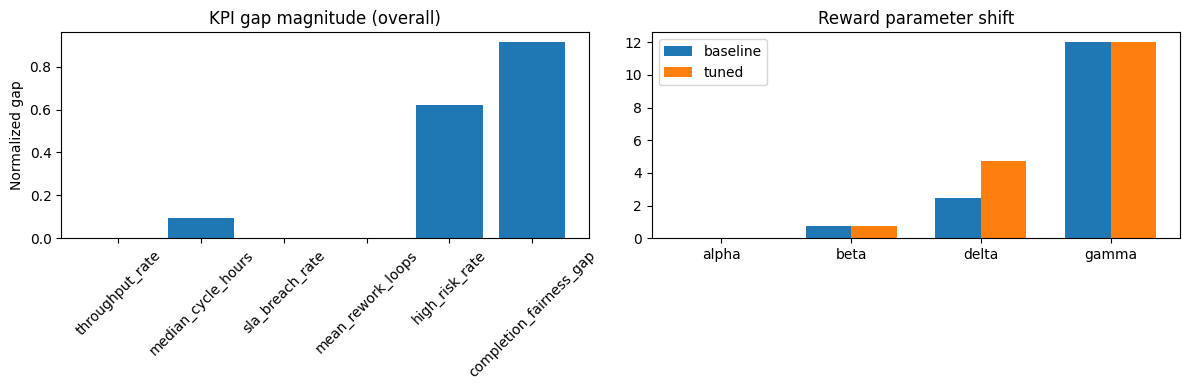

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(kpi_gap_df['kpi'], kpi_gap_df['gap'])
axes[0].set_title('KPI gap magnitude (overall)')
axes[0].set_ylabel('Normalized gap')
axes[0].tick_params(axis='x', rotation=45)

param_df = pd.DataFrame([
    {'param': k, 'baseline': base_params[k], 'tuned': tuned_params[k]}
    for k in ['alpha', 'beta', 'delta', 'gamma']
])
x = np.arange(len(param_df))
w = 0.35
axes[1].bar(x - w/2, param_df['baseline'], width=w, label='baseline')
axes[1].bar(x + w/2, param_df['tuned'], width=w, label='tuned')
axes[1].set_xticks(x)
axes[1].set_xticklabels(param_df['param'])
axes[1].set_title('Reward parameter shift')
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 5.5 complete

You now have KPI diagnostics and a tuned reward-parameter proposal saved for manager-level optimization:
- `./output/kpi_summary_by_municipality.csv`
- `./output/kpi_gap_summary.csv`
- `./output/reward_params_kpi_tuned.json`

Use `tuned_params` in Step 5/Step 6 RL training experiments and compare against baseline with Step 7 metrics.